In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

ROOT = os.path.join(os.path.dirname(os.getcwd()), '') if 'notebooks' in os.getcwd() else os.getcwd()
df = pd.read_csv(os.path.join(ROOT, 'results_all.csv'))

# Pair display names and ordering
PAIR_ORDER = [1, 2, 3, 4, 5, 6]
PAIR_LABELS = {
    1: 'Qwen3-VL\n30B / 235B',
    2: 'gpt-oss\n20B / 120B',
    3: 'Ministral\n3B / 14B',
    4: 'DeepSeek-V4\nFlash / Pro',
    5: 'Nemotron-3\nNano / Super',
    6: 'GLM-4.7\nFlash / 4.7',
}

SMALL_COLOR = '#4C72B0'
LARGE_COLOR = '#DD8452'

print(f'Loaded {len(df)} trials across {df["model_dir"].nunique()} models')
df.head(2)

Loaded 900 trials across 12 models


,model_dir,model_short,model,task_idx,map_type,rep,issue_title,base_commit,input_tokens,output_tokens,...,n_ground_truth_files,model_pair,pair_name,model_size,provider,architecture,task_type,cached_tokens,cost_usd,cost_usd_uncached
0,deepinfra_Qwen_Qwen3-VL-30B-A3B-Instruct,Qwen3-VL-30B,deepinfra/Qwen/Qwen3-VL-30B-A3B-Instruct,0,ast_compact,0,AttributeError: 'NoneType' object has no attri...,ccabcf1fca906bfa6b65a3189c1c41061e6c1042,36727,1128,...,1,1,Qwen3-VL,small,deepinfra,MoE,single_file,0,0.006186,0.006186
1,deepinfra_Qwen_Qwen3-VL-30B-A3B-Instruct,Qwen3-VL-30B,deepinfra/Qwen/Qwen3-VL-30B-A3B-Instruct,0,ast_compact,1,AttributeError: 'NoneType' object has no attri...,ccabcf1fca906bfa6b65a3189c1c41061e6c1042,124774,17712,...,1,1,Qwen3-VL,small,deepinfra,MoE,single_file,0,0.029343,0.029343


In [18]:
def paired_bar(ax, metric, df, ylabel='', title='', pct=False, ylim=None):
    """Draw paired small/large bars per model pair with ±1 SD error bars."""
    stats = (
        df.groupby(['model_pair', 'model_size'])[metric]
          .agg(['mean', 'std'])
          .reset_index()
    )

    x      = np.arange(len(PAIR_ORDER))
    width  = 0.35
    offset = {'small': -width / 2, 'large': width / 2}
    colors = {'small': SMALL_COLOR, 'large': LARGE_COLOR}

    for size in ('small', 'large'):
        sub = stats[stats['model_size'] == size].set_index('model_pair')
        means = [sub.loc[p, 'mean'] if p in sub.index else np.nan for p in PAIR_ORDER]
        stds  = [sub.loc[p, 'std']  if p in sub.index else 0      for p in PAIR_ORDER]
        if pct:
            means = [m * 100 if not np.isnan(m) else np.nan for m in means]
            stds  = [s * 100 for s in stds]
        ax.bar(
            x + offset[size], means, width,
            label=size.capitalize(),
            color=colors[size],
            yerr=stds,
            capsize=4,
            error_kw={'elinewidth': 1.2, 'ecolor': 'black', 'alpha': 0.7},
            alpha=0.88,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([PAIR_LABELS[p] for p in PAIR_ORDER], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    if ylim:
        ax.set_ylim(ylim)
    return ax

## 1 — Accuracy: F1, Precision, Recall

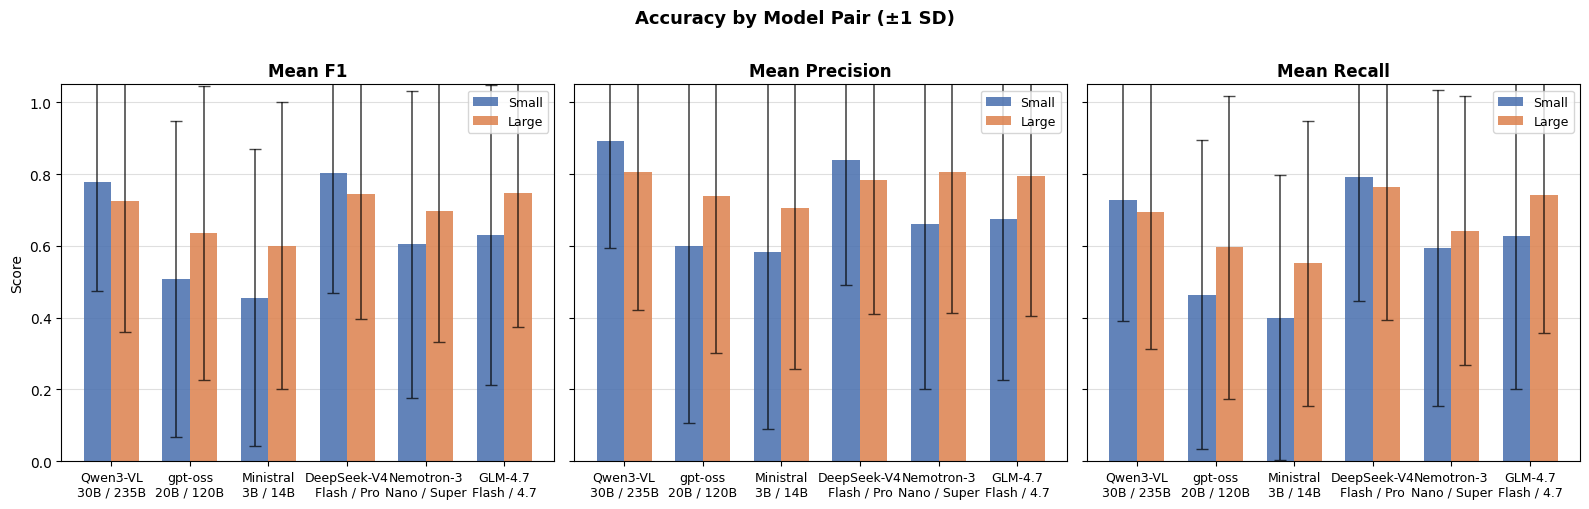

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

paired_bar(axes[0], 'f1',        df, ylabel='Score', title='Mean F1',        ylim=(0, 1.05))
paired_bar(axes[1], 'precision', df, ylabel='',      title='Mean Precision',  ylim=(0, 1.05))
paired_bar(axes[2], 'recall',    df, ylabel='',      title='Mean Recall',     ylim=(0, 1.05))

fig.suptitle('Accuracy by Model Pair (±1 SD)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2 — F1 by Map Condition

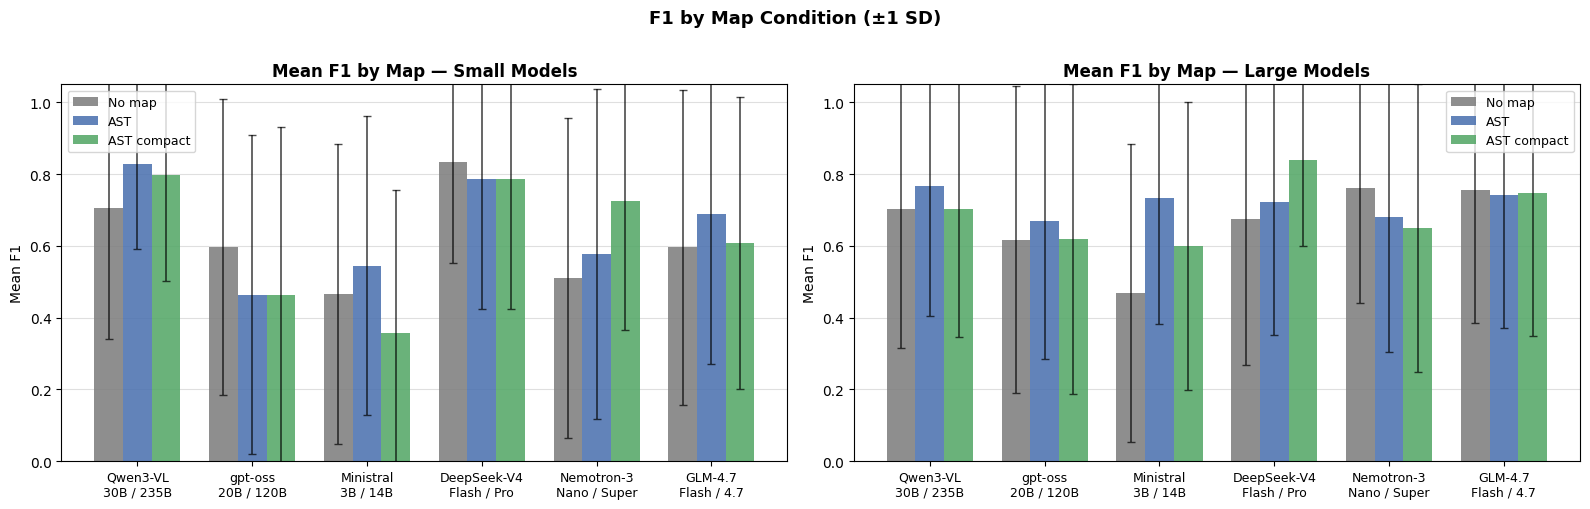

In [20]:
MAP_COLORS = {'none': '#7f7f7f', 'ast': '#4C72B0', 'ast_compact': '#55A868'}
MAP_LABELS = {'none': 'No map', 'ast': 'AST', 'ast_compact': 'AST compact'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, size in enumerate(('small', 'large')):
    ax = axes[ax_idx]
    sub = df[df['model_size'] == size]
    stats = (
        sub.groupby(['model_pair', 'map_type'])['f1']
           .agg(['mean', 'std'])
           .reset_index()
    )
    maps = ['none', 'ast', 'ast_compact']
    x = np.arange(len(PAIR_ORDER))
    w = 0.25
    offsets = [-w, 0, w]

    for i, m in enumerate(maps):
        s = stats[stats['map_type'] == m].set_index('model_pair')
        means = [s.loc[p, 'mean'] if p in s.index else np.nan for p in PAIR_ORDER]
        stds  = [s.loc[p, 'std']  if p in s.index else 0      for p in PAIR_ORDER]
        ax.bar(
            x + offsets[i], means, w,
            label=MAP_LABELS[m],
            color=MAP_COLORS[m],
            yerr=stds,
            capsize=3,
            error_kw={'elinewidth': 1.2, 'ecolor': 'black', 'alpha': 0.7},
            alpha=0.88,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([PAIR_LABELS[p] for p in PAIR_ORDER], fontsize=9)
    ax.set_ylabel('Mean F1')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Mean F1 by Map — {size.capitalize()} Models', fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

fig.suptitle('F1 by Map Condition (±1 SD)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_f1_by_map.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3 — F1 by Task

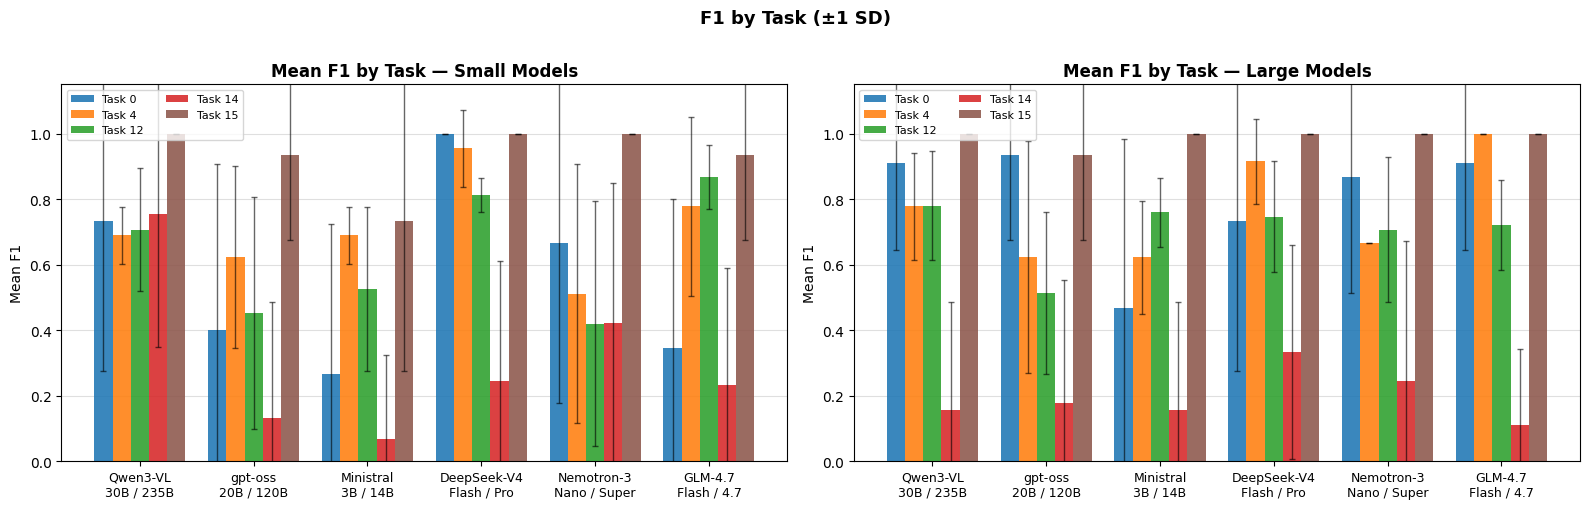

In [21]:
TASKS = sorted(df['task_idx'].unique())
TASK_COLORS = plt.cm.tab10(np.linspace(0, 0.5, len(TASKS)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, size in enumerate(('small', 'large')):
    ax = axes[ax_idx]
    sub = df[df['model_size'] == size]
    stats = (
        sub.groupby(['model_pair', 'task_idx'])['f1']
           .agg(['mean', 'std'])
           .reset_index()
    )
    n = len(TASKS)
    x = np.arange(len(PAIR_ORDER))
    w = 0.8 / n
    offsets = np.linspace(-(n - 1) * w / 2, (n - 1) * w / 2, n)

    for i, task in enumerate(TASKS):
        s = stats[stats['task_idx'] == task].set_index('model_pair')
        means = [s.loc[p, 'mean'] if p in s.index else np.nan for p in PAIR_ORDER]
        stds  = [s.loc[p, 'std']  if p in s.index else 0      for p in PAIR_ORDER]
        ax.bar(
            x + offsets[i], means, w,
            label=f'Task {task}',
            color=TASK_COLORS[i],
            yerr=stds,
            capsize=2,
            error_kw={'elinewidth': 1, 'ecolor': 'black', 'alpha': 0.6},
            alpha=0.88,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([PAIR_LABELS[p] for p in PAIR_ORDER], fontsize=9)
    ax.set_ylabel('Mean F1')
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Mean F1 by Task — {size.capitalize()} Models', fontweight='bold')
    ax.legend(fontsize=8, ncol=2)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

fig.suptitle('F1 by Task (±1 SD)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_f1_by_task.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4 — Turns and Forced-Submit Rate

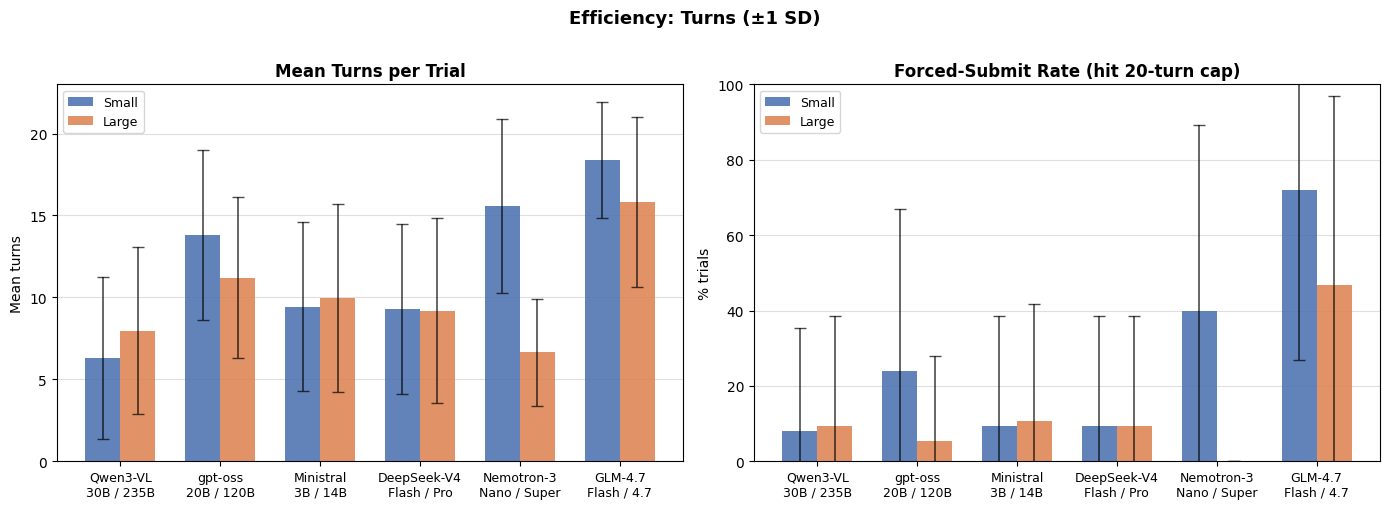

In [22]:
df['max_turns_flag'] = (df['stop_reason'] == 'max_turns').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

paired_bar(axes[0], 'turns',          df, ylabel='Mean turns',      title='Mean Turns per Trial')
paired_bar(axes[1], 'max_turns_flag', df, ylabel='% trials',        title='Forced-Submit Rate (hit 20-turn cap)', pct=True, ylim=(0, 100))

fig.suptitle('Efficiency: Turns (±1 SD)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_turns.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5 — Token Usage

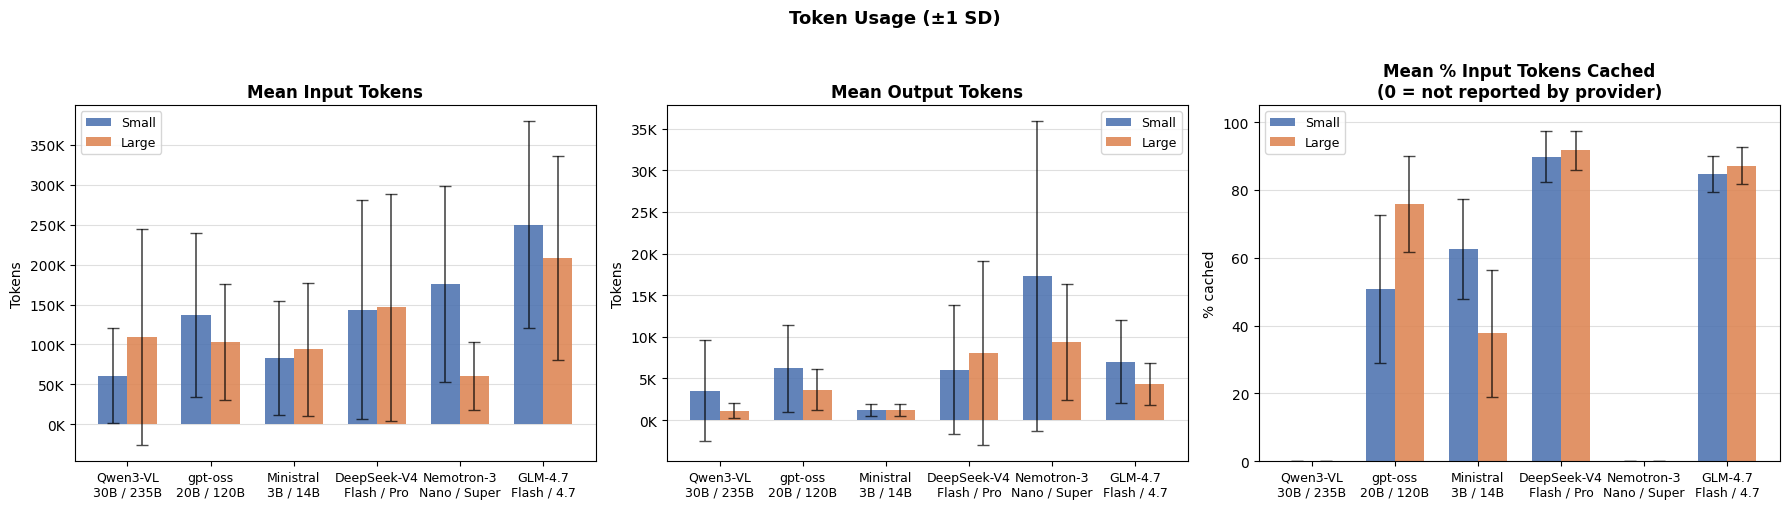

In [23]:
# Cached token % (only meaningful where > 0)
df['pct_cached'] = df['cached_tokens'] / df['input_tokens'].replace(0, np.nan) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

paired_bar(axes[0], 'input_tokens',  df, ylabel='Tokens',   title='Mean Input Tokens')
paired_bar(axes[1], 'output_tokens', df, ylabel='Tokens',   title='Mean Output Tokens')
paired_bar(axes[2], 'pct_cached',    df, ylabel='% cached', title='Mean % Input Tokens Cached\n(0 = not reported by provider)', ylim=(0, 105))

# Format y-axis with K suffix for token plots
for ax in axes[:2]:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))

fig.suptitle('Token Usage (±1 SD)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_tokens.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6 — Empty Prediction Rate

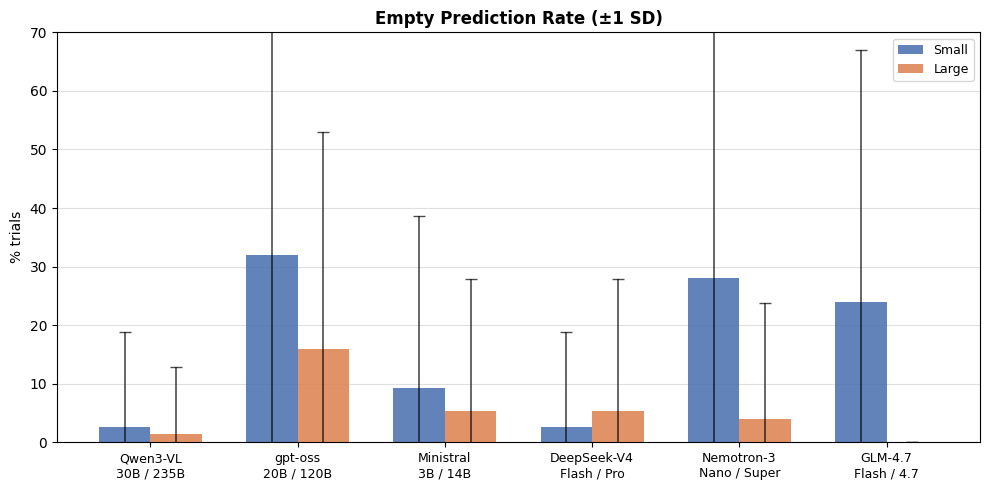

In [24]:
df['empty_flag'] = df['empty_prediction'].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
paired_bar(ax, 'empty_flag', df, ylabel='% trials', title='Empty Prediction Rate (±1 SD)', pct=True, ylim=(0, 70))

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_empty_rate.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7 — Stop Reason Breakdown (stacked bar)

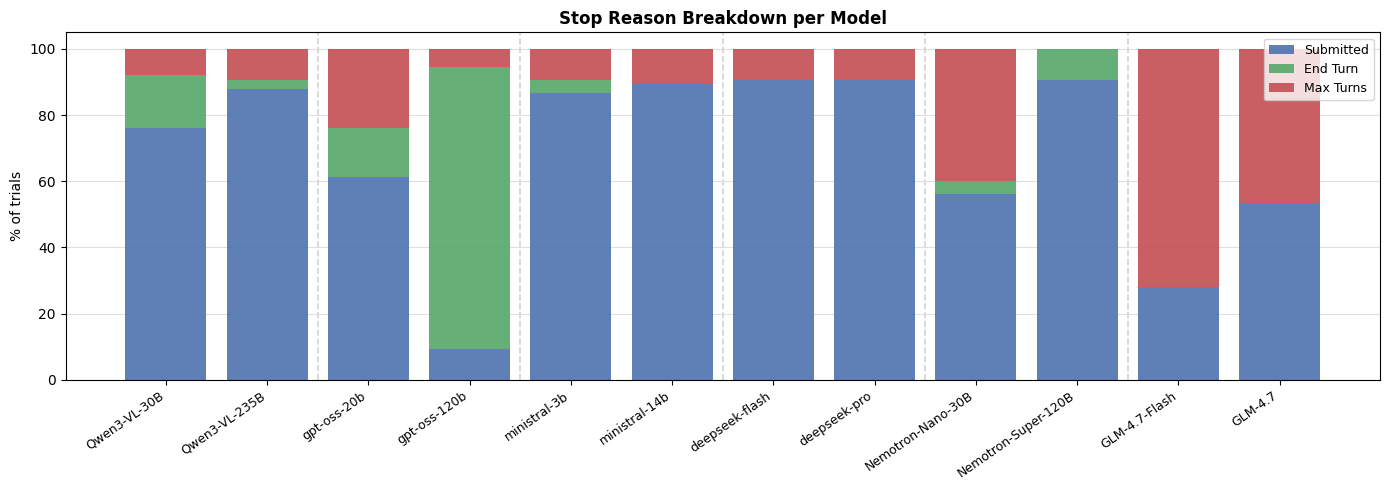

In [25]:
SHORT_ORDER = [
    'Qwen3-VL-30B', 'Qwen3-VL-235B',
    'gpt-oss-20b', 'gpt-oss-120b',
    'ministral-3b', 'ministral-14b',
    'deepseek-flash', 'deepseek-pro',
    'Nemotron-Nano-30B', 'Nemotron-Super-120B',
    'GLM-4.7-Flash', 'GLM-4.7',
]
SR_COLORS = {'submitted': '#4C72B0', 'end_turn': '#55A868', 'max_turns': '#C44E52'}

sr = (
    df.groupby(['model_short', 'stop_reason'])
      .size()
      .unstack(fill_value=0)
      .div(75) * 100
)
sr = sr.reindex(SHORT_ORDER)

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(sr))
x = np.arange(len(sr))

for reason in ['submitted', 'end_turn', 'max_turns']:
    if reason not in sr.columns:
        continue
    vals = sr[reason].values
    ax.bar(x, vals, bottom=bottom, label=reason.replace('_', ' ').title(),
           color=SR_COLORS[reason], alpha=0.9)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(SHORT_ORDER, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('% of trials')
ax.set_ylim(0, 105)
ax.set_title('Stop Reason Breakdown per Model', fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# Vertical separators between pairs
for sep in [1.5, 3.5, 5.5, 7.5, 9.5]:
    ax.axvline(sep, color='lightgrey', linewidth=1.2, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_stop_reason.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8 — F1 by Map Condition (small vs large, averaged across pairs)

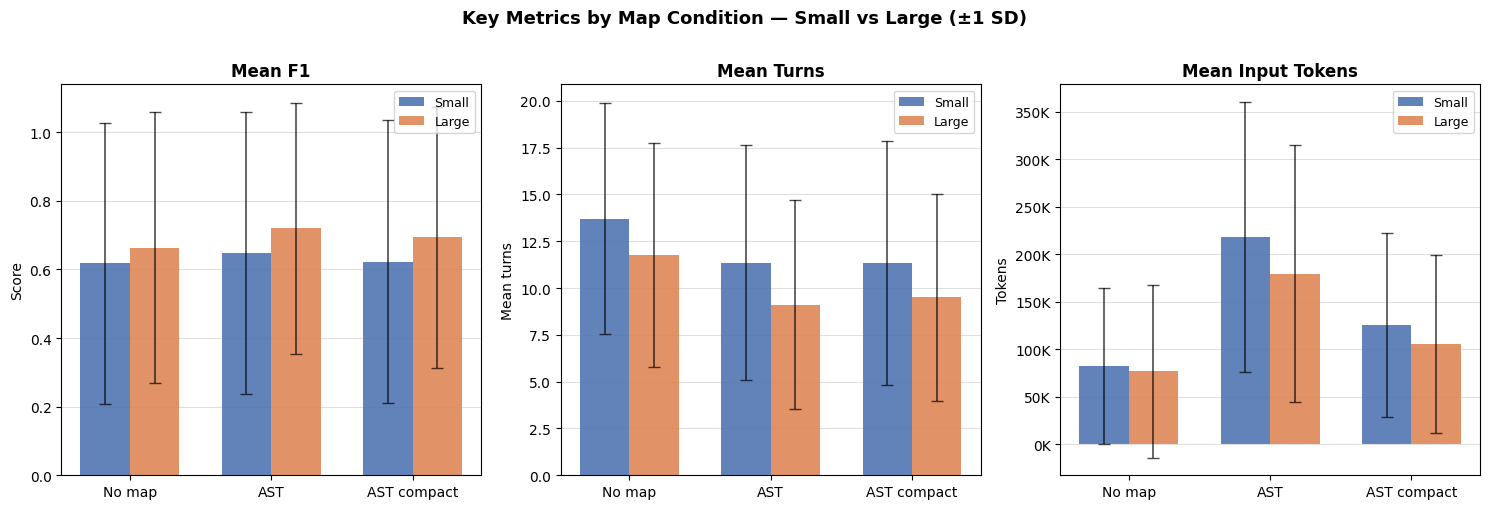

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, ylabel, title in [
    (axes[0], 'f1',        'Score',        'Mean F1'),
    (axes[1], 'turns',     'Mean turns',   'Mean Turns'),
    (axes[2], 'input_tokens', 'Tokens',    'Mean Input Tokens'),
]:
    stats = (
        df.groupby(['map_type', 'model_size'])[metric]
          .agg(['mean', 'std'])
          .reset_index()
    )
    maps   = ['none', 'ast', 'ast_compact']
    x      = np.arange(len(maps))
    width  = 0.35
    colors = {'small': SMALL_COLOR, 'large': LARGE_COLOR}

    for size in ('small', 'large'):
        sub   = stats[stats['model_size'] == size].set_index('map_type')
        means = [sub.loc[m, 'mean'] for m in maps]
        stds  = [sub.loc[m, 'std']  for m in maps]
        ax.bar(
            x + (-width/2 if size == 'small' else width/2),
            means, width,
            label=size.capitalize(),
            color=colors[size],
            yerr=stds,
            capsize=4,
            error_kw={'elinewidth': 1.2, 'ecolor': 'black', 'alpha': 0.7},
            alpha=0.88,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(['No map', 'AST', 'AST compact'], fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))

fig.suptitle('Key Metrics by Map Condition — Small vs Large (±1 SD)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_by_map.png'), dpi=150, bbox_inches='tight')
plt.show()


## 9 — F1 by Model and Map Condition

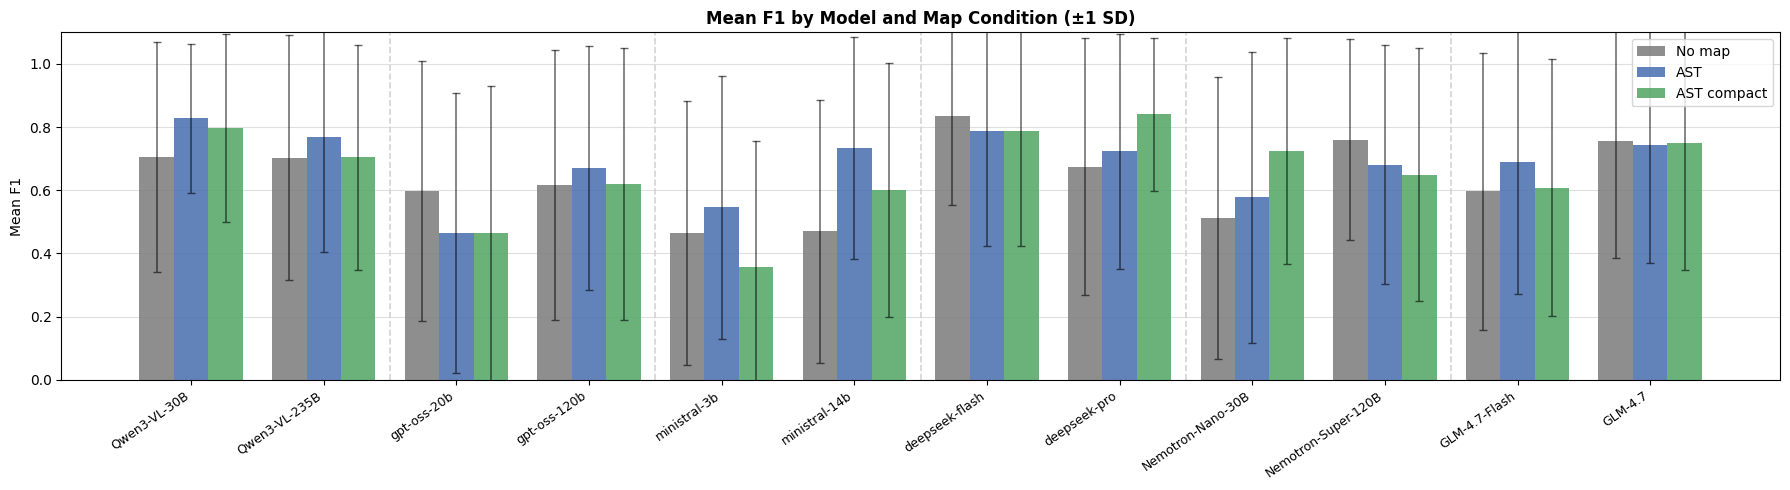

In [27]:
MAP_COLORS  = {'none': '#7f7f7f', 'ast': '#4C72B0', 'ast_compact': '#55A868'}
MAP_DISPLAY = {'none': 'No map', 'ast': 'AST', 'ast_compact': 'AST compact'}

stats = (
    df.groupby(['model_short', 'map_type'])['f1']
      .agg(['mean', 'std'])
      .reset_index()
)

x     = np.arange(len(SHORT_ORDER))
w     = 0.26
maps  = ['none', 'ast', 'ast_compact']
offs  = [-w, 0, w]

fig, ax = plt.subplots(figsize=(18, 5))

for i, m in enumerate(maps):
    sub   = stats[stats['map_type'] == m].set_index('model_short')
    means = [sub.loc[s, 'mean'] if s in sub.index else np.nan for s in SHORT_ORDER]
    stds  = [sub.loc[s, 'std']  if s in sub.index else 0      for s in SHORT_ORDER]
    ax.bar(
        x + offs[i], means, w,
        label=MAP_DISPLAY[m],
        color=MAP_COLORS[m],
        yerr=stds,
        capsize=3,
        error_kw={'elinewidth': 1.1, 'ecolor': 'black', 'alpha': 0.6},
        alpha=0.88,
    )

ax.set_xticks(x)
ax.set_xticklabels(SHORT_ORDER, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean F1')
ax.set_ylim(0, 1.1)
ax.set_title('Mean F1 by Model and Map Condition (±1 SD)', fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# Pair separators
for sep in [1.5, 3.5, 5.5, 7.5, 9.5]:
    ax.axvline(sep, color='lightgrey', linewidth=1.2, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_f1_by_model_map.png'), dpi=150, bbox_inches='tight')
plt.show()


## 10 — Wall Time per Model and Map Condition

> **Note:** wall time reflects both model speed and API/network latency and is not comparable across providers. Use within-provider comparisons only.

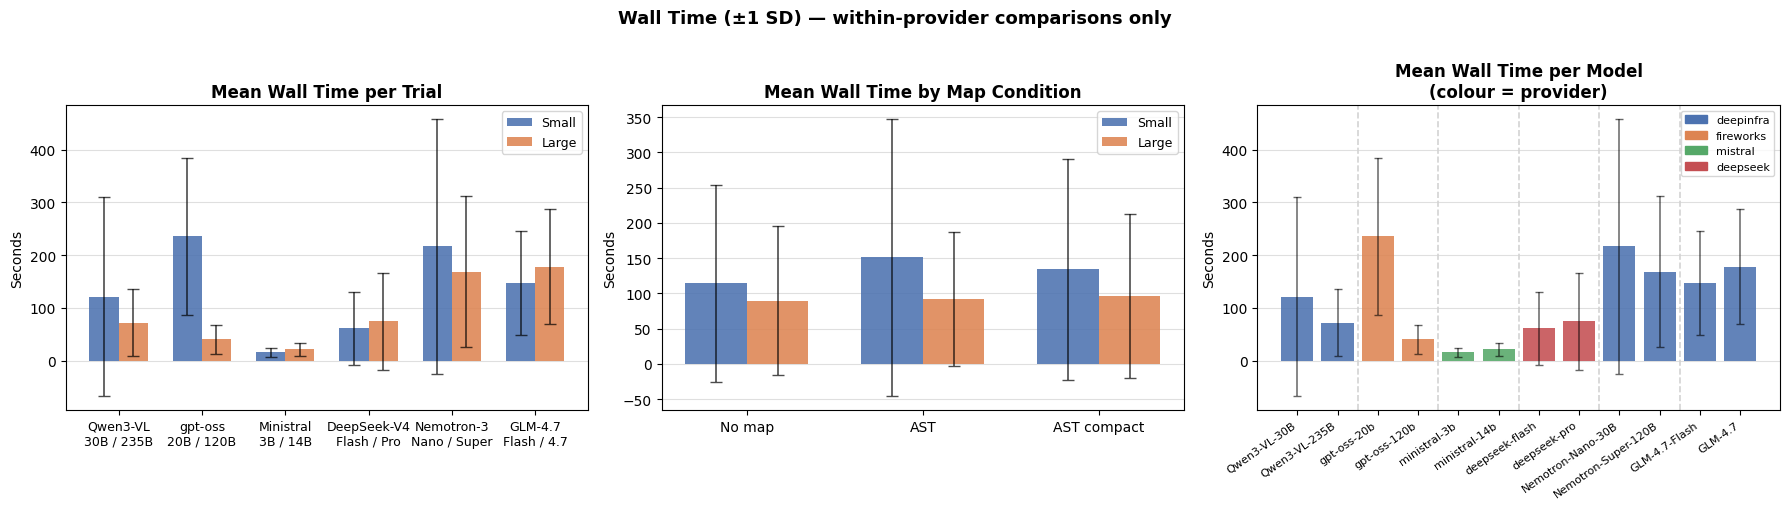

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: mean wall time per pair (small vs large)
paired_bar(axes[0], 'wall_time', df,
           ylabel='Seconds', title='Mean Wall Time per Trial')

# Panel 2: wall time by map condition (small vs large)
for size, color in [('small', SMALL_COLOR), ('large', LARGE_COLOR)]:
    sub   = df[df['model_size'] == size]
    stats = sub.groupby('map_type')['wall_time'].agg(['mean', 'std'])
    maps  = ['none', 'ast', 'ast_compact']
    x     = np.arange(len(maps))
    off   = -0.175 if size == 'small' else 0.175
    axes[1].bar(
        x + off,
        [stats.loc[m, 'mean'] for m in maps],
        0.35,
        label=size.capitalize(),
        color=color,
        yerr=[stats.loc[m, 'std'] for m in maps],
        capsize=4,
        error_kw={'elinewidth': 1.2, 'ecolor': 'black', 'alpha': 0.7},
        alpha=0.88,
    )
axes[1].set_xticks(np.arange(3))
axes[1].set_xticklabels(['No map', 'AST', 'AST compact'])
axes[1].set_ylabel('Seconds')
axes[1].set_title('Mean Wall Time by Map Condition', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].yaxis.grid(True, alpha=0.4)
axes[1].set_axisbelow(True)

# Panel 3: wall time per model (all 12, coloured by provider)
PROVIDER_COLORS = {
    'deepinfra': '#4C72B0',
    'fireworks': '#DD8452',
    'mistral':   '#55A868',
    'deepseek':  '#C44E52',
}
stats3 = df.groupby(['model_short', 'provider'])['wall_time'].agg(['mean', 'std']).reset_index()
stats3 = stats3.set_index('model_short').reindex(SHORT_ORDER).reset_index()
x3 = np.arange(len(SHORT_ORDER))
bar_colors = [PROVIDER_COLORS[p] for p in stats3['provider']]
axes[2].bar(x3, stats3['mean'], color=bar_colors, alpha=0.88,
            yerr=stats3['std'], capsize=3,
            error_kw={'elinewidth': 1.1, 'ecolor': 'black', 'alpha': 0.6})
axes[2].set_xticks(x3)
axes[2].set_xticklabels(SHORT_ORDER, rotation=35, ha='right', fontsize=8)
axes[2].set_ylabel('Seconds')
axes[2].set_title('Mean Wall Time per Model\n(colour = provider)', fontweight='bold')
axes[2].yaxis.grid(True, alpha=0.4)
axes[2].set_axisbelow(True)
# Pair separators
for sep in [1.5, 3.5, 5.5, 7.5, 9.5]:
    axes[2].axvline(sep, color='lightgrey', linewidth=1.2, linestyle='--')
# Provider legend
from matplotlib.patches import Patch
axes[2].legend(handles=[Patch(color=c, label=p) for p, c in PROVIDER_COLORS.items()], fontsize=8)

fig.suptitle('Wall Time (±1 SD) — within-provider comparisons only', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_wall_time.png'), dpi=150, bbox_inches='tight')
plt.show()


## 11 — Cost per Trial

> Computed from provider pricing × token counts. For models with a cache discount, cached tokens are billed at the reduced rate. **ministral-14b** pricing was supplied with DeepSeek listed as provider — verify if correct.

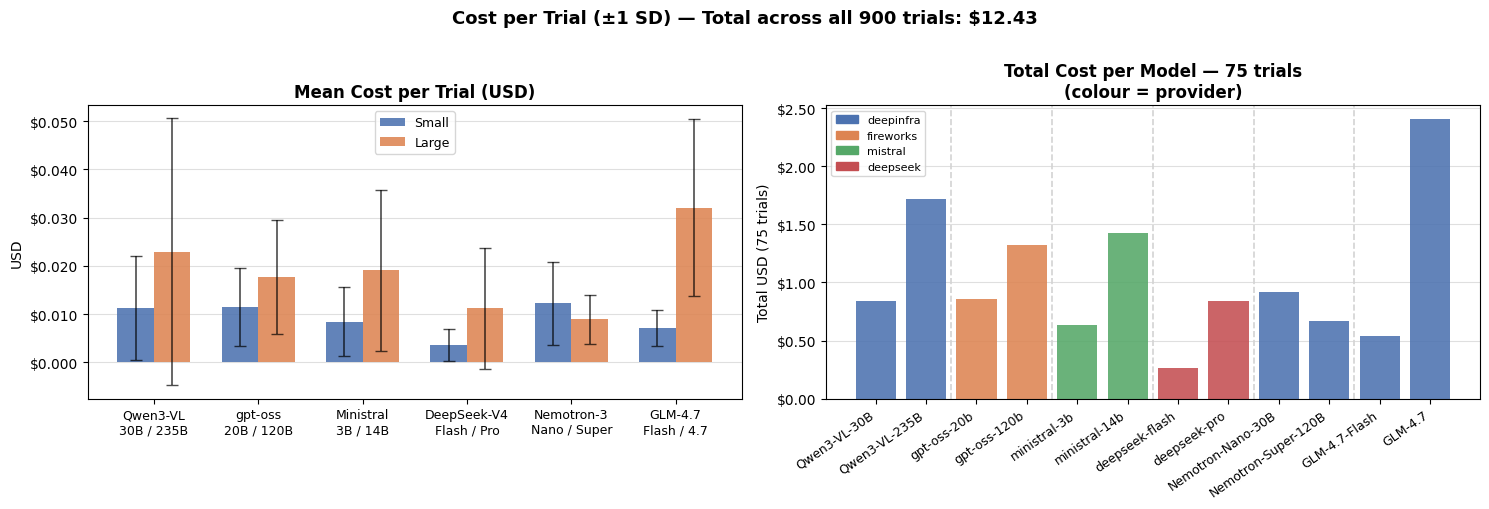

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: mean cost per trial by pair (small vs large)
paired_bar(axes[0], 'cost_usd', df,
           ylabel='USD', title='Mean Cost per Trial (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.3f}'))

# Panel 2: total cost per model (all 12, coloured by provider)
stats = df.groupby(['model_short', 'provider'])['cost_usd'].sum().reset_index()
stats = stats.set_index('model_short').reindex(SHORT_ORDER).reset_index()
x = np.arange(len(SHORT_ORDER))
bar_colors = [PROVIDER_COLORS[p] for p in stats['provider']]
axes[1].bar(x, stats['cost_usd'], color=bar_colors, alpha=0.88)
axes[1].set_xticks(x)
axes[1].set_xticklabels(SHORT_ORDER, rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('Total USD (75 trials)')
axes[1].set_title('Total Cost per Model — 75 trials\n(colour = provider)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.2f}'))
axes[1].yaxis.grid(True, alpha=0.4)
axes[1].set_axisbelow(True)
for sep in [1.5, 3.5, 5.5, 7.5, 9.5]:
    axes[1].axvline(sep, color='lightgrey', linewidth=1.2, linestyle='--')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=c, label=p) for p, c in PROVIDER_COLORS.items()], fontsize=8)

# Annotate total
total = df['cost_usd'].sum()
fig.suptitle(f'Cost per Trial (±1 SD) — Total across all 900 trials: ${total:.2f}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'results_fig_cost.png'), dpi=150, bbox_inches='tight')
plt.show()
